In [61]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from outliers import smirnov_grubbs as grubbs
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import statsmodels.api as sm
import pingouin as pg
from scipy.stats import kstest

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## 1. Выбрать уникальные для каждого студента в группе датасеты для выполнения заданий практикума. Подготовить их описание, краткие характеристики (максимумы-минимумы, средние значения, пропуски и т.п.).

In [62]:
ds = pd.read_csv('Health_Risk_Dataset.csv')
ds

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low
...,...,...,...,...,...,...,...,...,...,...
995,P0107,18,96,1,124,72,37.2,A,0,Normal
996,P0271,19,95,1,129,70,38.1,A,0,Low
997,P0861,39,82,1,101,137,37.5,A,1,High
998,P0436,15,92,1,106,108,38.6,A,0,Medium


### Расшифровка каждой колонки:

Patient_ID – уникальный анонимный идентификатор пациента

Respiratory_Rate – количество вдохов в минуту

Oxygen_Saturation – уровень насыщенности крови кислородом (%)

O2_Scale – шкала используемости кислородной терапии

Systolic_BP – систолическое артериальное давление (мм рт ст)

Heart_Rate – пульс в минуту

Temperature – температура тела (°C).

Consciousness – уровень сознания (A = тревога, P = реакция на боль, C = замешательство, V = вербальный, U = не реагирует).

On_Oxygen – получает ли пациент дополнительный кислород (0 = нет, 1 = да).

Risk_Level – целевая переменная (нормальный, низкий, средний, высокий).

In [63]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


Пропусков в нашем датасете нет

In [64]:
ds.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


## 2. Реализовать аппроксимацию распределений данных с помощью ядерных оценок

In [65]:
colomns_for_print = ['Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Heart_Rate', 'Temperature']

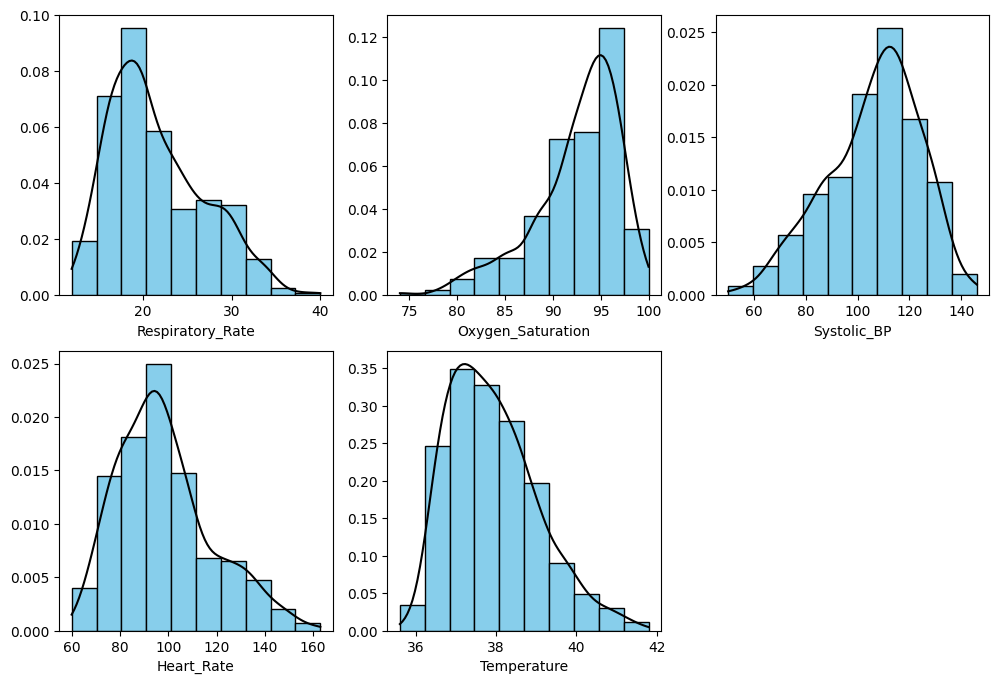

In [66]:
count = 0
plt.figure(figsize=(12, 8))
for i in colomns_for_print:
    count += 1
    plt.subplot(2, 3, count)
    data = ds[i]
    x = np.linspace(data.min(), data.max(), 100)
    plt.hist(data, density=True, color='skyblue', edgecolor='black')
    plt.xlabel(f'{i}')
    plt.plot(x, stats.gaussian_kde(data)(x), color='black')

## 3. Реализовать анализ данных с помощью cdplot, dotchart, boxplot и stripchart.

### 3.1 cdplot

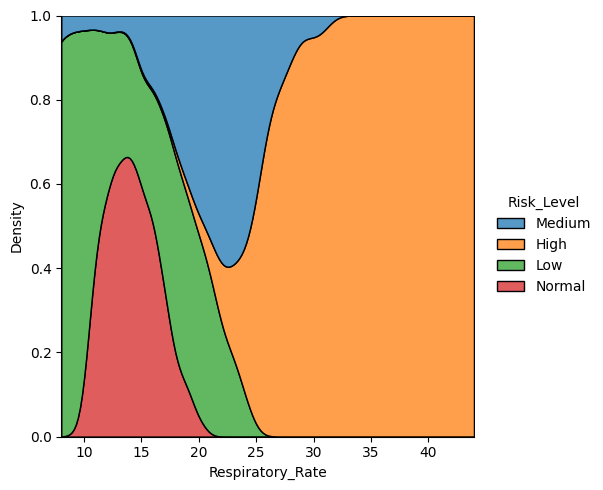

In [67]:
sns.displot(ds, x='Respiratory_Rate', hue='Risk_Level', kind='kde', multiple='fill')

### 3.2 dotchart

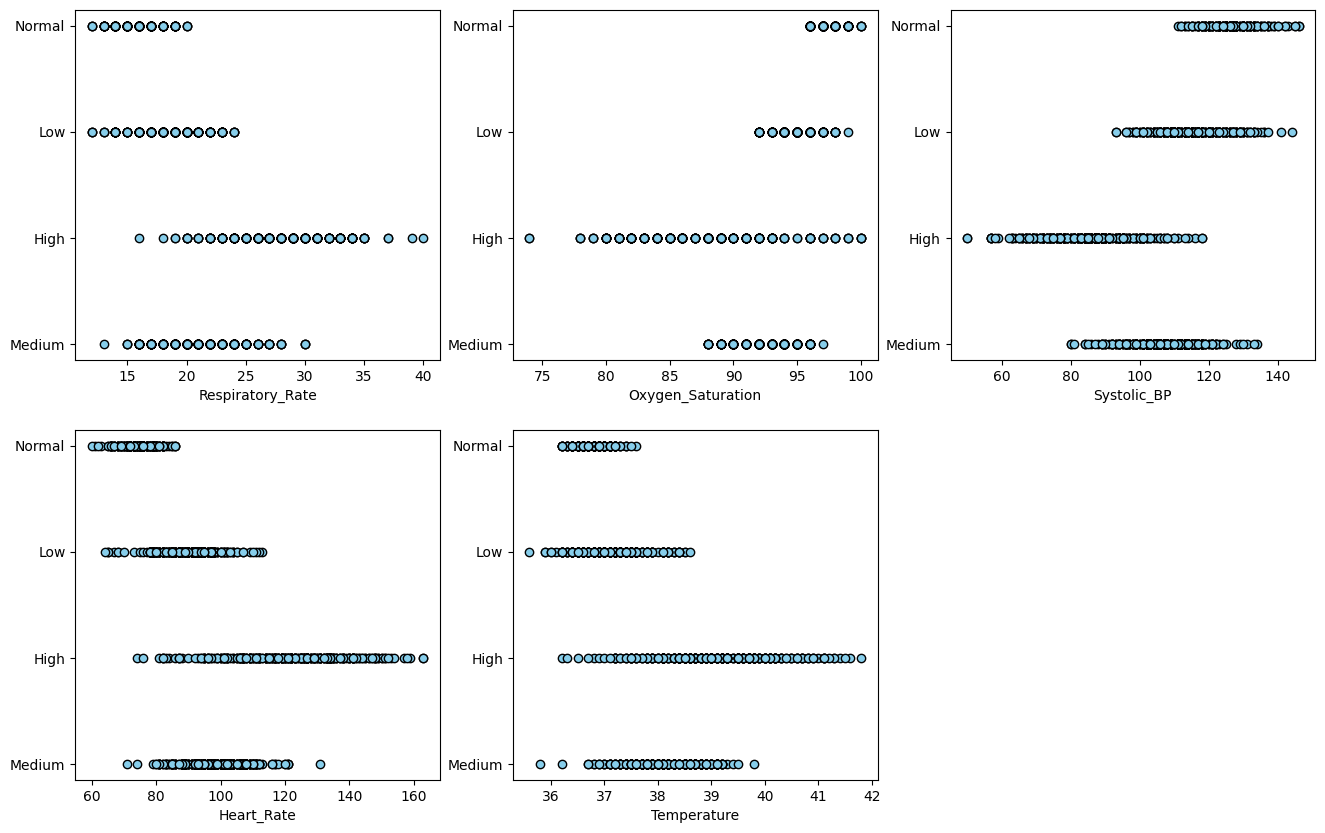

In [68]:
count = 0
plt.figure(figsize=(16, 10))
for i in colomns_for_print:
    count += 1
    plt.subplot(2, 3, count)
    plt.scatter(ds[i], ds['Risk_Level'], color='skyblue', edgecolor='black')
    plt.xlabel(f'{i}')

### 3.3 boxplot

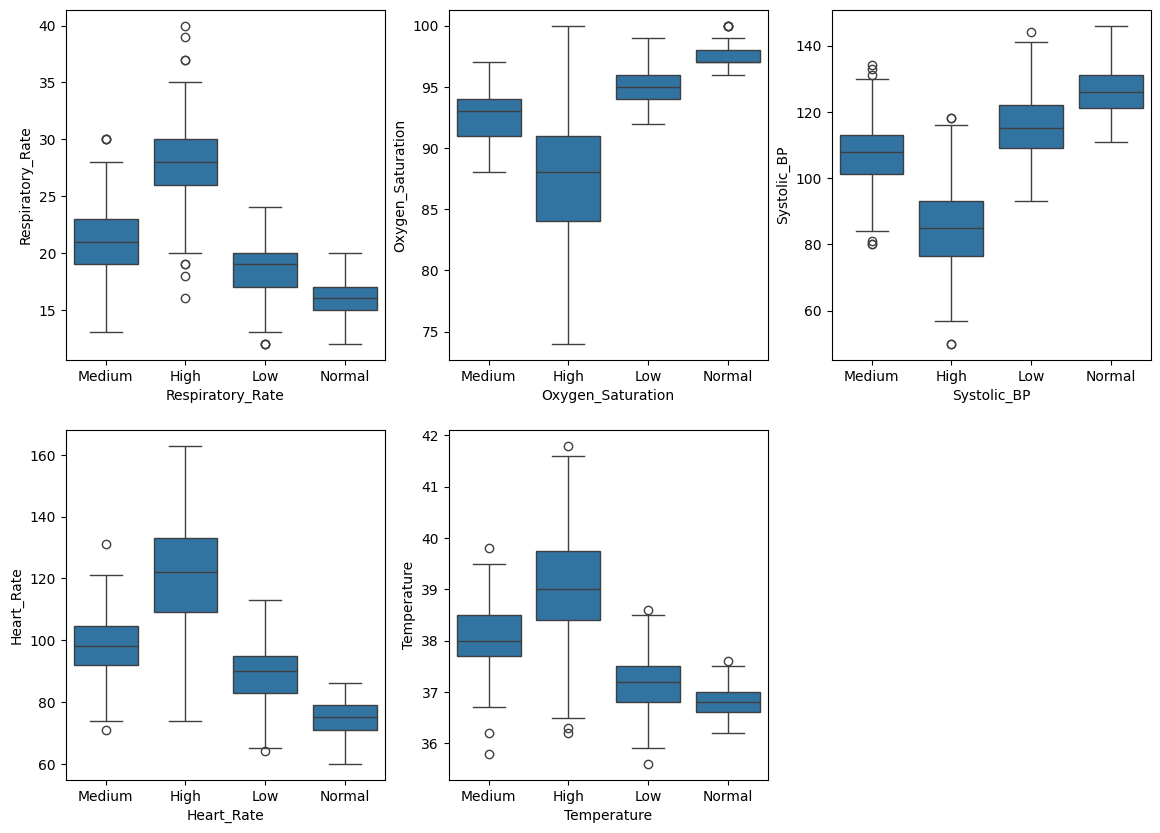

In [69]:
count = 0
plt.figure(figsize=(14, 10))
for i in colomns_for_print:
    count += 1
    plt.subplot(2, 3, count)
    sns.boxplot(ds, x='Risk_Level', y=i)
    plt.xlabel(f'{i}')

### 3.4 stripchart

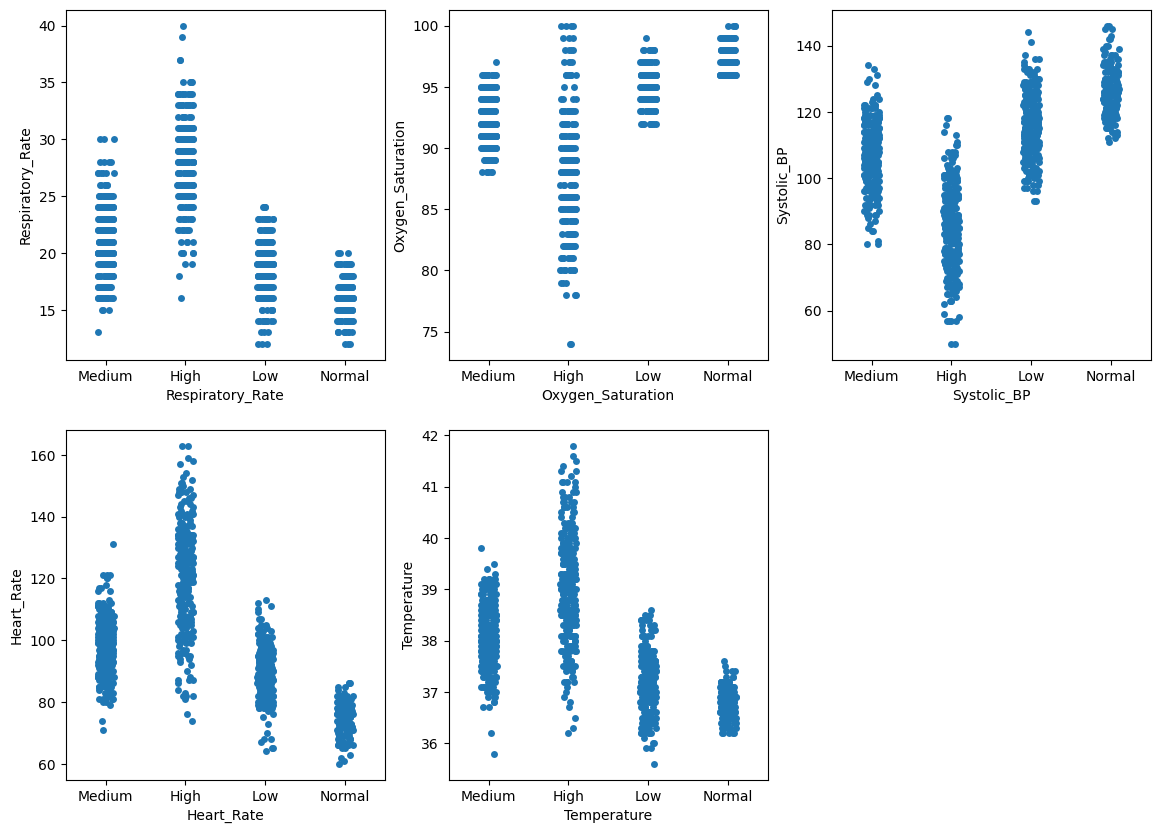

In [70]:
count = 0
plt.figure(figsize=(14, 10))
for i in colomns_for_print:
    count += 1
    plt.subplot(2, 3, count)
    sns.stripplot(ds, x='Risk_Level', y=i)
    plt.xlabel(f'{i}')

## 4. Проверить, являются ли наблюдения выбросами с точки зрения формальных статистических критериев Граббса и Q-теста Диксона. Визуализировать результаты. 

### 4.1 Критерий Граббса

In [71]:
data = np.random.normal(0, 1, 1000)
ind = grubbs.max_test_indices(data, alpha=0.5)
for j in ind:
    print(data[j], end=' ')

4.149300797443454 3.2971043029961007 

<Axes: >

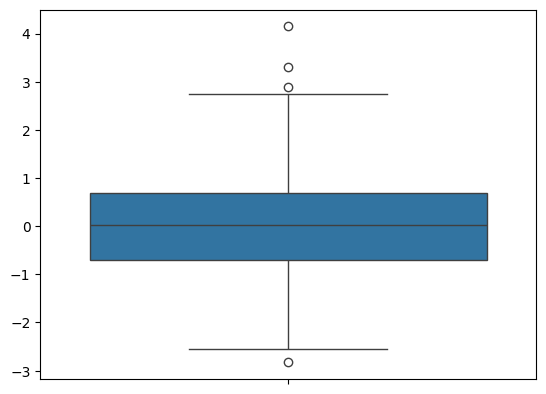

In [72]:
sns.boxplot(data)

Тест показывает, что выброс в Oxygen_Saturation: значение 74

### 4.2 Q-тест Диксона

Q-тест Диксона реализован только в R, поэтому на python реализации не приводится

## 5. Воспользоваться инструментами для заполнения пропусков в данных. Пропуски внести вручную и сравнить результаты заполнения с истинными значениями. 

In [73]:
sp = ds.copy()
sp['Heart_Rate'][0:10] = None
sp

C:\Users\aleks\AppData\Local\Temp\ipykernel_19560\3772967562.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sp['Heart_Rate'][0:10] = None
C:\Users\aleks\AppData\Local\Temp\ipykernel_19560\3772967562.py:2: SettingWithCopyWarning: 
A valu

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,NaN,37.5,A,0,Medium
1,P0738,28,92,2,116,NaN,38.5,P,1,High
2,P0741,29,91,1,79,NaN,38.4,A,0,High
3,P0661,24,96,1,95,NaN,37.3,A,0,Medium
4,P0412,20,96,1,97,NaN,37.4,A,0,Low
...,...,...,...,...,...,...,...,...,...,...
995,P0107,18,96,1,124,72.0,37.2,A,0,Normal
996,P0271,19,95,1,129,70.0,38.1,A,0,Low
997,P0861,39,82,1,101,137.0,37.5,A,1,High
998,P0436,15,92,1,106,108.0,38.6,A,0,Medium


Text(0.5, 1.0, 'Исходное')

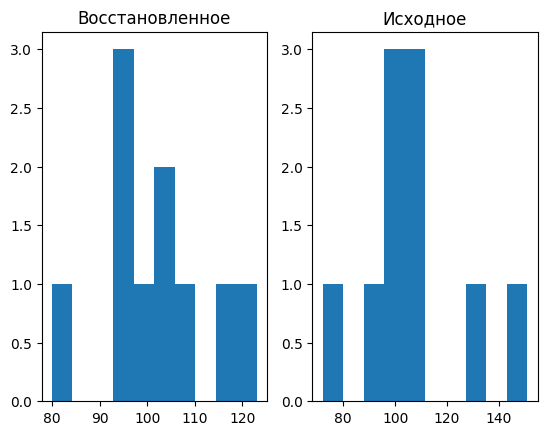

In [74]:
cat_col = sp.select_dtypes(include=['object']).columns
for i in cat_col:
    sp[i] = pd.factorize(sp[i])[0]
imp = IterativeImputer()
imp.fit(sp)
sp_imp = imp.transform(sp)
sp = pd.DataFrame(sp_imp, columns=sp.columns)

plt.subplot(1, 2, 1)
plt.hist(sp['Heart_Rate'][0:10])
plt.title('Восстановленное')

plt.subplot(1, 2, 2)
plt.hist(ds['Heart_Rate'][0:10])
plt.title('Исходное')

## 6. Сгенерировать данные из нормального распределения с различными параметрами и провести анализ с помощью графиков эмпирических функций распределений, квантилей, метода огибающих, а также стандартных процедур проверки гипотез о нормальности (критерии Колмогорова-Смирнова, ШапироУилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия). Рассмотреть выборки малого (не более 50-100 элементов) и умеренного (1000-5000 наблюдений) объемов

### 6.1 Генерация данных и графики эмчирических функций распределения

In [75]:
data_1 = np.random.normal(0, 1, 2000)
data_2 = np.random.normal(0, 3, 2000)
data_3 = np.random.normal(1, 4, 2000)
data_4 = np.random.normal(5, 8, 75)
data_5 = np.random.normal(9, 2, 75)

data_arr = [data_1, data_2, data_3, data_4, data_5]
count = 0

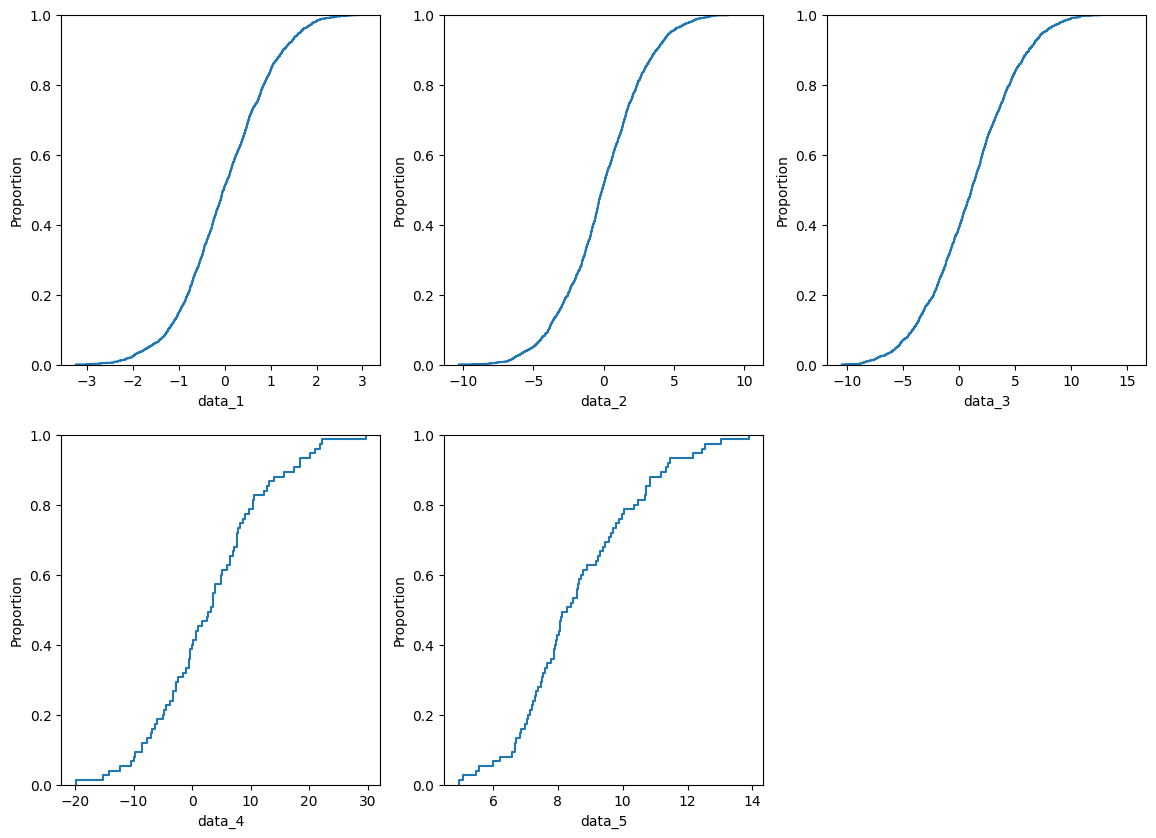

In [76]:
plt.figure(figsize=(14, 10))
for i in range(1, 6):
    plt.subplot(2, 3, i)
    sns.ecdfplot(data_arr[i - 1])
    plt.xlabel(f'data_{i}')

### 6.2 Квантили

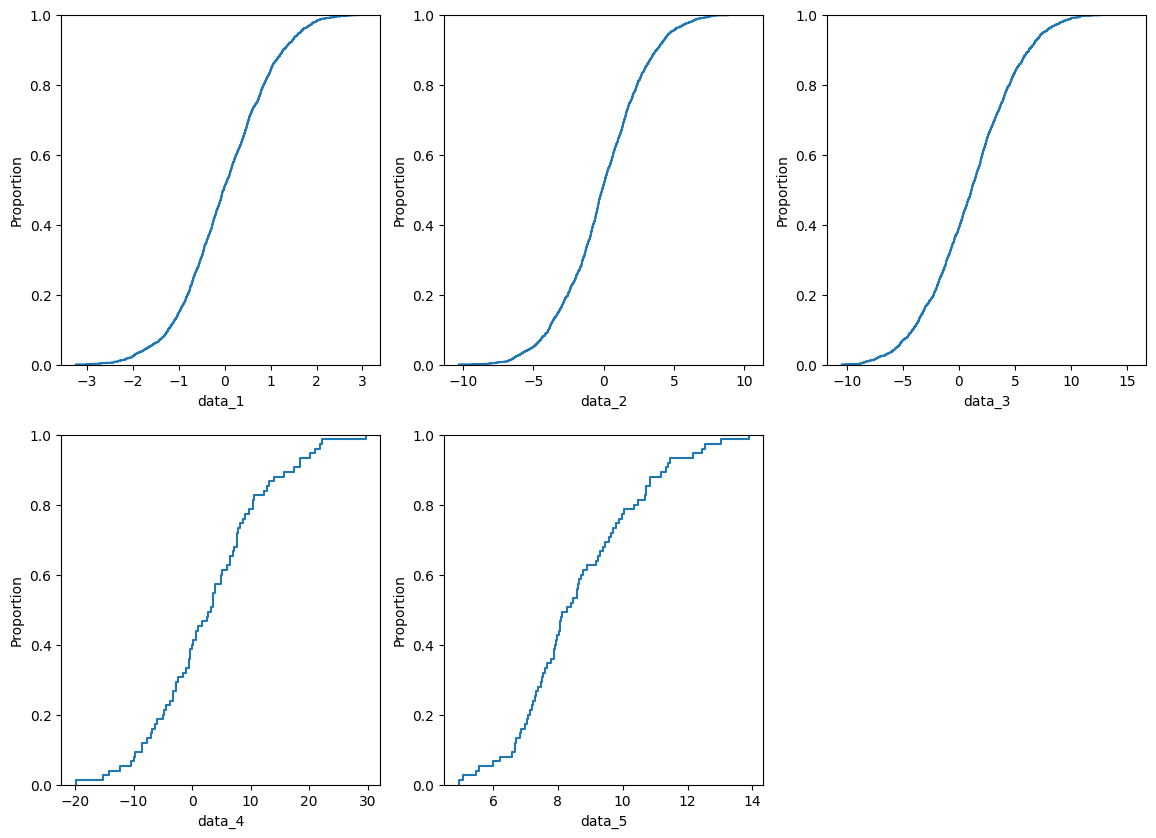

In [77]:
plt.figure(figsize=(14, 10))
for i in range(1, 6):
    plt.subplot(2, 3, i)
    sns.ecdfplot(data_arr[i - 1])
    plt.xlabel(f'data_{i}')

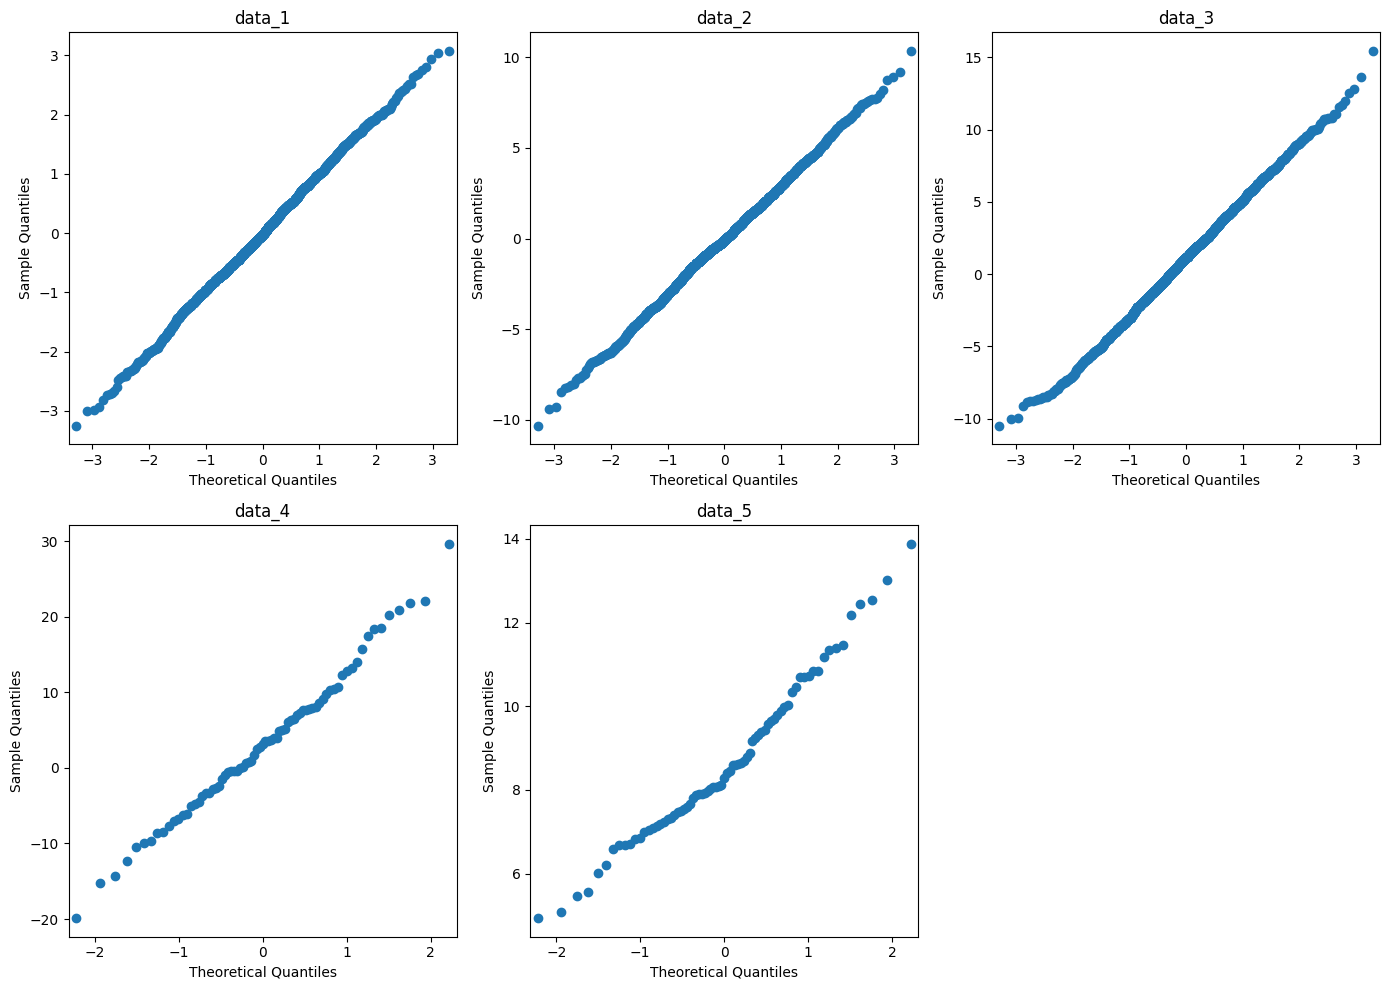

In [78]:
plt.figure(figsize=(14, 10))
for i in range(1, 6):
    plt.subplot(2, 3, i)
    sm.qqplot(data_arr[i - 1], ax=plt.gca())
    plt.title(f"data_{i}")
plt.tight_layout()
plt.show()

### 6.3 Метод огибающих

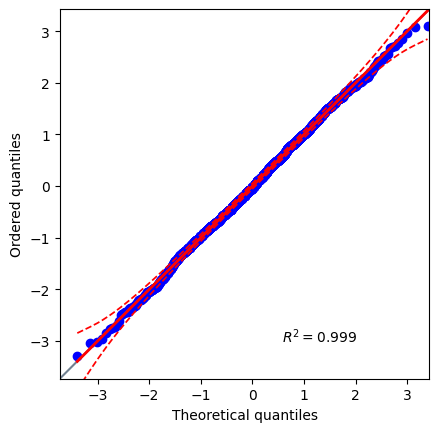

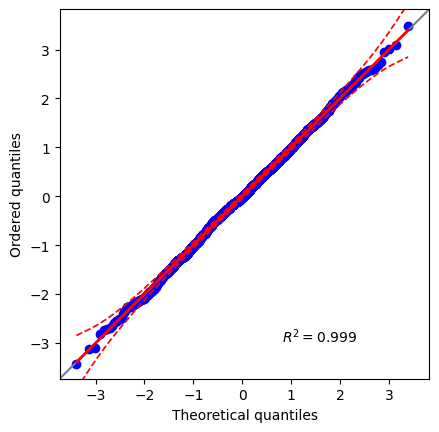

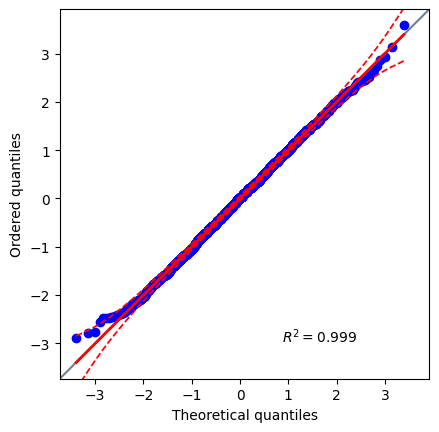

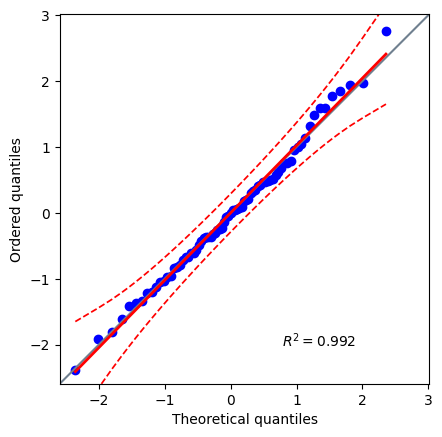

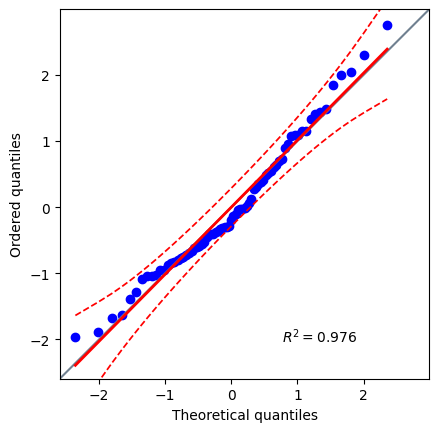

In [79]:
for i in range(5):
    pg.qqplot(data_arr[i], dist='norm', confidence=0.95)
    plt.show()

### 6.4 Критерий Колмогорова-Смирнова

In [80]:
mu = [0, 0, 1, 5, 9]
sig = [1, 3, 4, 8, 2]

In [81]:
for i in range(5):
    print("data_" + str(i + 1), kstest(data_arr[i], 'norm', args=(mu[i], sig[i])))

data_1 KstestResult(statistic=np.float64(0.014609920348734373), pvalue=np.float64(0.7810031852655925), statistic_location=np.float64(-0.049174592135107255), statistic_sign=np.int8(1))
data_2 KstestResult(statistic=np.float64(0.017501605640973916), pvalue=np.float64(0.5664370492259445), statistic_location=np.float64(0.15044866096502024), statistic_sign=np.int8(1))
data_3 KstestResult(statistic=np.float64(0.017091559120848143), pvalue=np.float64(0.5968838897355108), statistic_location=np.float64(0.9908914977542347), statistic_sign=np.int8(-1))
data_4 KstestResult(statistic=np.float64(0.14690091024448843), pvalue=np.float64(0.07077031657641242), statistic_location=np.float64(0.952093406096644), statistic_sign=np.int8(1))
data_5 KstestResult(statistic=np.float64(0.16329475162574808), pvalue=np.float64(0.032443476016359885), statistic_location=np.float64(8.12038673473239), statistic_sign=np.int8(1))


### 6.5 Критерий Шапиро-Уилка

In [82]:
for i in range(5):
    print("data_" + str(i + 1), stats.shapiro(data_arr[i]))

data_1 ShapiroResult(statistic=np.float64(0.9990817690509453), pvalue=np.float64(0.4141365870646543))
data_2 ShapiroResult(statistic=np.float64(0.9992205856245195), pvalue=np.float64(0.5792683963599817))
data_3 ShapiroResult(statistic=np.float64(0.9989894502166863), pvalue=np.float64(0.3225385188124541))
data_4 ShapiroResult(statistic=np.float64(0.9929532334626591), pvalue=np.float64(0.9555261975300074))
data_5 ShapiroResult(statistic=np.float64(0.9746891300056548), pvalue=np.float64(0.13773791043273836))


### 6.6 Критерий Андерсона-Дарлинга

In [83]:
for i in range(5):
    print("data_" + str(i + 1), stats.anderson(data_arr[i]))

data_1 AndersonResult(statistic=np.float64(0.48958070724347635), critical_values=array([0.575, 0.655, 0.785, 0.916, 1.09 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(0.001923103461626134), scale=np.float64(0.9886712889148774))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
data_2 AndersonResult(statistic=np.float64(0.6154628195524765), critical_values=array([0.575, 0.655, 0.785, 0.916, 1.09 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-0.05452973723432095), scale=np.float64(2.987370257843898))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
data_3 AndersonResult(statistic=np.float64(0.24733822541793415), critical_values=array([0.575, 0.655, 0.785, 0.916, 1.09 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(1.082234495813326), s

### 6.7 Критерий Крамера фон Мизеса

In [84]:
for i in range(5):
    print("data_" + str(i + 1), stats.cramervonmises(data_arr[i], 'norm', args=(mu[i], sig[i])))

data_1 CramerVonMisesResult(statistic=0.07314850597019443, pvalue=0.7324445886957593)
data_2 CramerVonMisesResult(statistic=0.1596512074923096, pvalue=0.36148494608198434)
data_3 CramerVonMisesResult(statistic=0.11478148816735886, pvalue=0.5171960287847974)
data_4 CramerVonMisesResult(statistic=0.5069092912876585, pvalue=0.037973015348517714)
data_5 CramerVonMisesResult(statistic=0.5094399867059529, pvalue=0.037412646809848904)


### 6.8 Критерий Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия

In [85]:
from statsmodels.stats.diagnostic import lilliefors

for i in range(5):
    print("data_" + str(i + 1), lilliefors(data_arr[i], 'norm'))

data_1 (np.float64(0.015609437951217164), np.float64(0.2986352543721909))
data_2 (np.float64(0.021967029534243454), np.float64(0.022939894985000764))
data_3 (np.float64(0.013184950884453511), np.float64(0.5607161154256659))
data_4 (np.float64(0.05049347223076173), np.float64(0.9388754586362466))
data_5 (np.float64(0.10345038748498198), np.float64(0.06641091071552314))


In [86]:
from sfrancia import shapiroFrancia

for i in range(5):
    print("data_" + str(i + 1), shapiroFrancia(data_arr[i]))

data_1 {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9992365964765979), 'statistics z': np.float64(-0.10116630731900392), 'p-value': np.float64(0.5402907788363599)}
data_2 {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9992584382955808), 'statistics z': np.float64(-0.17066725061014237), 'p-value': np.float64(0.56775729240259)}
data_3 {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9991309874722519), 'statistics z': np.float64(0.20905738532732054), 'p-value': np.float64(0.4172017205927291)}
data_4 {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9925534135776091), 'statistics z': np.float64(-1.210456807515461), 'p-value': np.float64(0.8869481724962157)}
data_5 {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9763396177174872), 'statistics z': np.float64(1.0322637170545752), 'p-value': np.float64(0.1509742966368336)}


In [87]:
for i in range(5):
    print("data_" + str(i + 1), lilliefors(data_arr[i], 'norm'))

data_1 (np.float64(0.015609437951217164), np.float64(0.2986352543721909))
data_2 (np.float64(0.021967029534243454), np.float64(0.022939894985000764))
data_3 (np.float64(0.013184950884453511), np.float64(0.5607161154256659))
data_4 (np.float64(0.05049347223076173), np.float64(0.9388754586362466))
data_5 (np.float64(0.10345038748498198), np.float64(0.06641091071552314))


## 7. Продемонстрировать пример анализа данных с помощью графиков квантилей, метода огибающих, а также стандартных процедур проверки гипотез о нормальности. Рассмотреть выборки малого и умеренного объемов

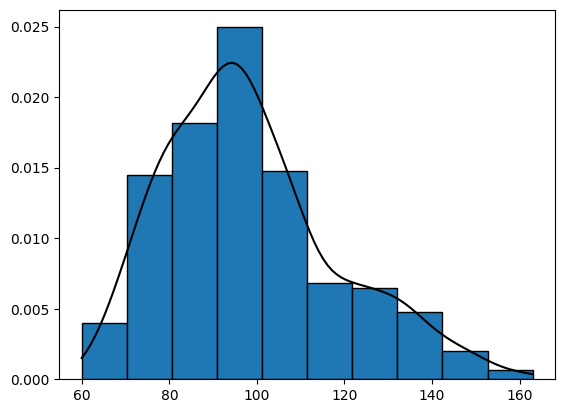

In [88]:
data_1 = ds['Heart_Rate']
data_2 = ds['Heart_Rate'][50:100]
plt.hist(data_1, edgecolor='black', density=True)
plt.plot(np.linspace(data_1.min(), data_1.max(), 100), stats.gaussian_kde(data_1)(np.linspace(data_1.min(), data_1.max(), 100)), color='black')

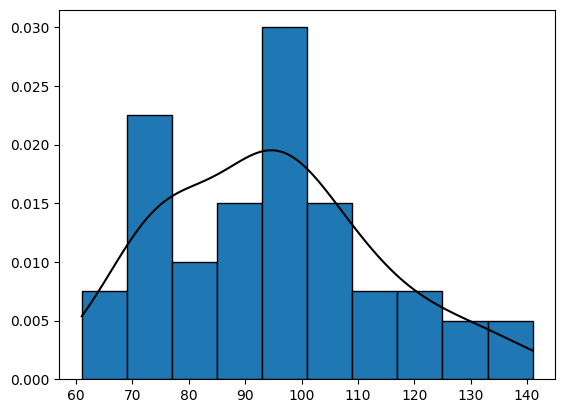

In [89]:
plt.hist(data_2, edgecolor='black', density=True)
plt.plot(np.linspace(data_2.min(), data_2.max(), 100), stats.gaussian_kde(data_2)(np.linspace(data_2.min(), data_2.max(), 100)), color='black')

### 7.1 Квантили

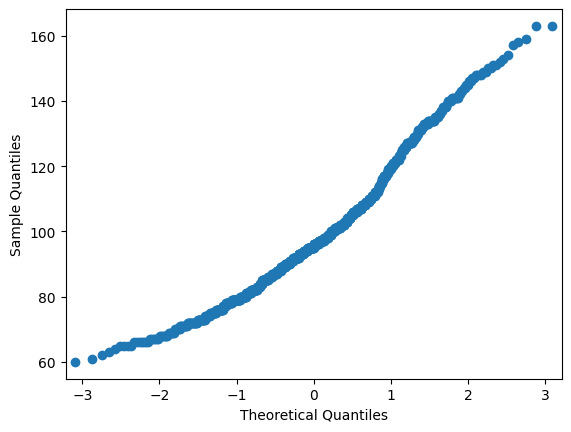

In [90]:
sm.qqplot(data_1)
plt.show()

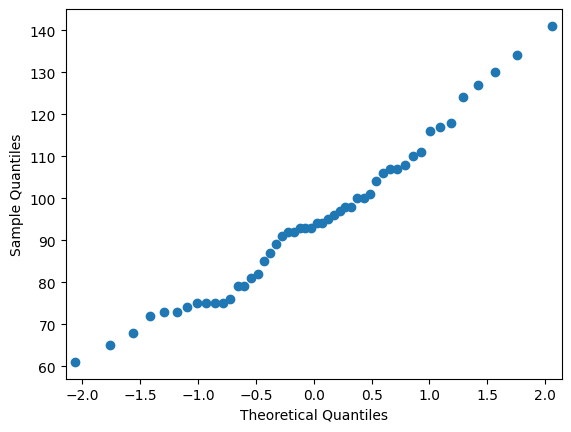

In [91]:
sm.qqplot(data_2)
plt.show()

### 7.2 Анализ с помощью метода огибающих

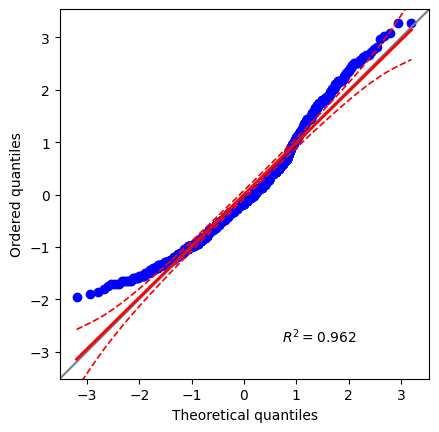

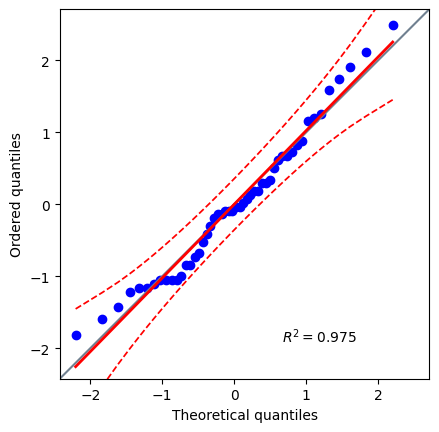

In [92]:
pg.qqplot(data_1, dist='norm', confidence=0.95)
plt.show()
pg.qqplot(data_2, dist='norm', confidence=0.95)
plt.show()

### 7.3 Гипотезы о нормальности

In [93]:
datas = [data_1, data_2]
for i in range(2):
    print("data_" + str(i + 1))
    print(kstest(datas[i], 'norm', args=(np.mean(datas[i]), np.std(datas[i]))))
    print(stats.shapiro(datas[i]))
    print(stats.anderson(datas[i]))
    print(stats.cramervonmises(datas[i], 'norm', args=(np.mean(datas[i]), np.std(datas[i]))))
    print(lilliefors(datas[i], 'norm'))
    print(shapiroFrancia(datas[i]))
    print('----------------------------------------------')

data_1
KstestResult(statistic=np.float64(0.08266548064973922), pvalue=np.float64(2.156505101631212e-06), statistic_location=np.int64(101), statistic_sign=np.int8(1))
ShapiroResult(statistic=np.float64(0.9614148897680148), pvalue=np.float64(1.3446115158965283e-15))
AndersonResult(statistic=np.float64(10.921159364917457), critical_values=array([0.574, 0.653, 0.784, 0.914, 1.088]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(98.46), scale=np.float64(19.69462561914489))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
CramerVonMisesResult(statistic=1.7523008322861044, pvalue=4.569592345970985e-05)
(np.float64(0.08269101226540598), np.float64(0.0009999999999998899))
{'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9620317730231905), 'statistics z': np.float64(7.418335867382082), 'p-value': np.float64(5.93005160836124e-14)}
----------------------------------------------
d